<a href="https://colab.research.google.com/github/m4vi/SimuladoSistemaArquivos/blob/main/Trabalho_I_Aprendizado_de_Heur%C3%ADsticas_Parte_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 1 - Aprendizado de Heurísticas

Este documento é parte da primeira avaliação prática da disciplina de inteligência artificial ministrada em 2025 na UFMT. O Trabalho é dividido em três partes.

Essa é a parte I e trata do aprendizado de heurísticas para o quebra-cabeça de oito peças (algoritmo **$A^*$**).


**Esta é uma atividade individual. Escreva sua própria solução.**
---
Autor: raoni.teixeira@ufmt.br

---

# Objetivo do Trabalho

O objetivo deste trabalho é desenvolver heurísticas de avaliação por meio de simulações e análise de dados para dois problemas clássicos estudados na disciplina:

- o Quebra-cabeça de Oito Peças e

- o Lig4.

## Sua Missão

A sua missão é investigar. Projete e conduza experimentos para responder a uma pergunta que genuinamente desperte a sua curiosidade sobre um desses jogos,  heurísticas ou algoritmos.

Não escolha um tema qualquer. Pense naquilo que te intriga. Por exemplo:

- A profundidade de busca na árvore do jogo afeta a qualidade da heurística aprendida?

- O que faz uma heurística ser superior à outra?

- A heurística evolui e melhora  ao longo do treinamento?

- A heurística treinada para o quebra-cabeça é admissível (não superestima o custo real)? É possível garantir isso?

- A qualidade da heurística depende do volume de dados de treinamento?

- Qual é a eficiência máxima que um algoritmo pode atingir com uma heurística ideal?



## Conselho importante

Coloque a mão na massa. Crie uma hipótese: "O que deveria acontecer?".
Depois, execute o experimento e confronte a teoria com a realidade. Funcionou? Não funcionou? Por quê? A *busca por essa resposta* é o objetivo dessa atividade.


Você deve apresentar suas descobertas ao professor. O objetivo central não é apenas mostrar resultados, mas sim demonstrar o que você aprendeu durante todo este processo.

# Heurísticas

Uma heurística é um atalho inteligente. Na prática, é uma função que avalia rapidamente uma posição ou decisão, indicando se ela é promissora ou não.

Como encontrar a solução perfeita frequentemente exige tempo ou recursos impraticáveis, a heurística nos ajuda a tomar uma decisão "boa o suficiente".

Exemplo 1: [Quebra-cabeça de Oito Peças](https://colab.research.google.com/drive/1lRYUHiIA77OBWzu3KkXc1EzPJrA8suNj?usp=sharing)
A heurística da distância Manhattan calcula, para cada peça, o número mínimo de movimentos necessários para posicioná-la corretamente. Se h(n) = 2, o estado está mais próximo da solução do que outro com h(n) = 5.

Exemplo 2: [Lig4](https://colab.research.google.com/drive/1DF-y_-dJ4IDs04iLByUHYiKnxWQfHQJy?usp=sharing)
Não é possível simular todas as partidas até o fim. Então, limitamos a busca a uma certa profundidade e usamos uma heurística para estimar se a posição atual é vantajosa para o jogador.

Em resumo: heurísticas não garantem o resultado ideal, mas orientam o algoritmo pelos caminhos mais promissores.


# Parte I - Heurística para o Quebra-cabeça de 8 Peças (5,0 pontos)



O código abaixo calcula o número mínimo de movimentos para um estado qualquer do quebra-cabeça.

O dicionário `dist[u]`  é a heurística perfeita (distância correta) e guarda quantos movimentos são necessários para alcançar o estado objetivo a partir do estado `u`.

In [ ]:
from collections import deque

import numpy as np
from scipy.signal import convolve2d as conv2
import matplotlib
from queue import PriorityQueue
import time
import random

class Estado:
  def __init__(self, pai=None, matriz=None):
      self.pai = pai
      self.matriz = matriz

      self.d = 0  # custo do caminho (g(n))
      self.p = 0   # prioridade (f(n) = g(n) + h(n))

  def __eq__(self, other):
      return np.array_equal(self.matriz, other.matriz)

  def __hash__(self):
      return hash(tuple(self.matriz.flatten()))  # para usar em conjuntos

  def __lt__(self, other):
    if(self.p<other.p):
      return True
    else:
      return False

  def mostrar(self):
    for linha in self.matriz:
        for elemento in linha:
            print(" " if elemento == 9 else elemento, end=" ")
        print()
    print()

  def __str__(self):
    return str(self.matriz)

def acoes_permitidas(estado):

  adj = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]])
  blank = estado.matriz==9
  mask = conv2(blank, adj, 'same')

  return estado.matriz[np.where(mask)]

def movimentar(s, c):

  matriz = s.matriz.copy()
  matriz[np.where(s.matriz==9)] = c
  matriz[np.where(s.matriz==c)] = 9

  return Estado(matriz=matriz)

def bfs_reverse(goal_state):
    dist = {goal_state: 0}
    queue = deque([goal_state])

    while queue:
        state = queue.popleft()
        d = dist[state]

        for c in acoes_permitidas(state):  # gera todos os estados possíveis a partir do atual
            next_state = movimentar (state, c)
            if next_state not in dist:
                dist[next_state] = d + 1
                queue.append(next_state)

    return dist

target = Estado(matriz=np.array([[1, 2, 3], [4, 5, 6],[7, 8, 9]]))
dist = bfs_reverse(target)

#Exemplo
u = Estado(matriz=np.array([[6,2,5],[7,1,8],[9,3,4]]))
print("Estado:")
u.mostrar()
print("Distancia ate o objetivo: ", dist[u])

Estado:
6 2 5 
7 1 8 
  3 4 

Distancia ate o objetivo:  22


Para calcular a distância correta, utilizamos a busca em largura reversa (`bfs_reverse`). A busca funciona como uma onda que parte do objetivo e avança de forma uniforme para os estados vizinhos. Começamos atribuindo distância zero ao estado objetivo (`target`). Em seguida visitamos todos os estados a um movimento de distância, depois os que estão a dois movimentos, e assim por diante — círculos concêntricos se afastando de uma pedra lançada na água.

A fila garante que todos os estados alcançáveis serão visitados. Cada estado descoberto entra na fila e, quando processado, produz seus vizinhos. O algoritmo segue assim até não restar nenhum estado conectado ao objetivo que ainda não tenha sido explorado.

As distâncias encontradas são ótimas porque a busca em largura sempre identifica primeiro o caminho mais curto. Quando um estado é visitado pela primeira vez, ele já está na menor distância possível do objetivo; como o algoritmo avança por níveis, não existe chance de descobrir depois um caminho melhor.

A abordagem também é eficiente: cada estado é processado uma única vez. O dicionário de distâncias registra imediatamente a menor distância encontrada, funcionando como memória permanente (i.e. *memoização*).

# Sua solução


Como `dist` é um mapa com o número mínimo de movimento que cada estado `s` precisa para chegar ao objetivo, você pode treinar um modelo linear (regressão linear) ou não linear (rede neural) para prever `dist`.

Teste diferentes abordagens para responder sua pergunta.

Por exemplo, imagine que podemos extrair de cada estado `s` um conjunto de características `[f₁(s), f₂(s), ..., fₙ(s)]`. Nossa heurística será uma combinação linear dessas características:

**`h(s) = w₀ + w₁·f₁(s) + w₂·f₂(s) + ... + wₙ·fₙ(s)`**

Onde `w` é um vetor de pesos que aprenderemos.

## Características Possíveis

As características representam informações úteis do estado, como:

- **Medidas clássicas**: distância Hamming, distância Manhattan
- **Relações entre peças**: quantidade de peças com vizinhos corretos  
- **Posições individuais**: localização de cada peça (1, 2, 3, ..., 8)

## Sua Tarefa

1. **Implemente**: Escolha um conjunto de características e crie a função para extraí-las de qualquer estado
2. **Aprenda**: Encontre os pesos ideais e avalie a qualidade da heurística resultante



Código completo para gerar todos os estados e dataset

In [1]:
from collections import deque
import numpy as np
from scipy.signal import convolve2d as conv2
import pandas as pd

class Estado:
    def __init__(self, pai=None, matriz=None):
        self.pai = pai
        self.matriz = matriz

    def __eq__(self, other):
        return np.array_equal(self.matriz, other.matriz)

    def __hash__(self):
        return hash(tuple(self.matriz.flatten()))

    def __str__(self):
        return str(self.matriz)

def acoes_permitidas(estado):
    adj = np.array([[0,1,0],[1,0,1],[0,1,0]])
    blank = estado.matriz == 9
    mask = conv2(blank, adj, 'same')
    return estado.matriz[np.where(mask)]

def movimentar(s, c):
    matriz = s.matriz.copy()
    matriz[np.where(s.matriz == 9)] = c
    matriz[np.where(s.matriz == c)] = 9
    return Estado(matriz=matriz)

def bfs_reverse(goal_state):
    dist = {goal_state:0}
    queue = deque([goal_state])

    while queue:
        state = queue.popleft()
        d = dist[state]

        for c in acoes_permitidas(state):
            next_state = movimentar(state, c)

            if next_state not in dist:
                dist[next_state] = d + 1
                queue.append(next_state)

    return dist


# Estado objetivo
target = Estado(matriz=np.array([[1,2,3],[4,5,6],[7,8,9]]))

print("Calculando todos os estados...")
dist = bfs_reverse(target)

print("Total de estados encontrados:", len(dist))

Calculando todos os estados...
Total de estados encontrados: 181440


Extração de características (features)

Agora vamos extrair características de cada estado.

In [4]:
goal_positions = {
    1:(0,0),2:(0,1),3:(0,2),
    4:(1,0),5:(1,1),6:(1,2),
    7:(2,0),8:(2,1)
}

def pecas_fora_do_lugar(m):
    count = 0
    goal = np.array([[1,2,3],[4,5,6],[7,8,9]])
    for i in range(3):
        for j in range(3):
            if m[i,j] != 9 and m[i,j] != goal[i,j]:
                count += 1
    return count


def distancia_manhattan(m):
    dist = 0
    for i in range(3):
        for j in range(3):
            val = m[i,j]
            if val != 9:
                gi, gj = goal_positions[val]
                dist += abs(i-gi) + abs(j-gj)
    return dist

Criar dataset completo

Agora geramos dados para todos os estados.

In [5]:
data = []

for estado, d in dist.items():

    m = estado.matriz

    f1 = pecas_fora_do_lugar(m)
    f2 = distancia_manhattan(m)

    data.append([f1, f2, d])


df = pd.DataFrame(data, columns=[
    "pecas_fora",
    "manhattan",
    "dist_real"
])

print(df.head())
print("Total de exemplos:", len(df))

   pecas_fora  manhattan  dist_real
0           0          0          0
1           1          1          1
2           1          1          1
3           2          2          2
4           2          2          2
Total de exemplos: 181440


Treinar heurística com regressão

In [6]:
from sklearn.linear_model import LinearRegression

X = df[["pecas_fora","manhattan"]]
y = df["dist_real"]

model = LinearRegression()
model.fit(X,y)

print("Pesos aprendidos:", model.coef_)
print("Intercepto:", model.intercept_)

Pesos aprendidos: [-0.60727652  0.77394517]
Intercepto: 15.455577057842543


Testar a heurística

In [7]:
erro = abs(model.predict(X) - y).mean()
print("Erro médio:", erro)

Erro médio: 2.1810038246917163


1 Preparar os dados (features mais completas)

Além de peças fora do lugar e Manhattan, vamos usar mais características para ajudar a rede a aprender melhor.

In [8]:
goal_positions = {
    1:(0,0),2:(0,1),3:(0,2),
    4:(1,0),5:(1,1),6:(1,2),
    7:(2,0),8:(2,1)
}

def extrair_features(m):

    # peças fora do lugar
    misplaced = 0

    # manhattan
    manhattan = 0

    # peças na linha correta
    linha_certa = 0

    # peças na coluna correta
    coluna_certa = 0

    for i in range(3):
        for j in range(3):

            val = m[i,j]

            if val == 9:
                continue

            gi, gj = goal_positions[val]

            if val != (i*3 + j + 1):
                misplaced += 1

            manhattan += abs(i-gi) + abs(j-gj)

            if i == gi:
                linha_certa += 1

            if j == gj:
                coluna_certa += 1

    return [misplaced, manhattan, linha_certa, coluna_certa]

2 Construir dataset completo

In [9]:
data = []

for estado, d in dist.items():

    features = extrair_features(estado.matriz)

    data.append(features + [d])

import pandas as pd

df = pd.DataFrame(data, columns=[
    "misplaced",
    "manhattan",
    "linha_certa",
    "coluna_certa",
    "dist_real"
])

3 Separar treino e teste

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["dist_real"])
y = df["dist_real"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4 Treinar rede neural

In [11]:
from sklearn.neural_network import MLPRegressor

modelo_nn = MLPRegressor(
    hidden_layer_sizes=(32,16),
    activation="relu",
    max_iter=200
)

modelo_nn.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(32, 16))

5 Avaliar desempenho

In [12]:
from sklearn.metrics import mean_absolute_error

pred = modelo_nn.predict(X_test)

erro = mean_absolute_error(y_test, pred)

print("Erro médio da rede neural:", erro)

Erro médio da rede neural: 2.005813375714071


6 Comparar com regressão linear

In [13]:
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

pred_lin = modelo_linear.predict(X_test)

erro_lin = mean_absolute_error(y_test, pred_lin)

print("Erro regressão linear:", erro_lin)
print("Erro rede neural:", erro)

Erro regressão linear: 2.0571809501144793
Erro rede neural: 2.005813375714071


7 Usar a rede como heurística

In [16]:
def heuristica_nn(estado):

    features = extrair_features(estado.matriz)

    df_features = pd.DataFrame(
        [features],
        columns=["misplaced","manhattan","linha_certa","coluna_certa"]
    )

    return modelo_nn.predict(df_features)[0]

8 A heurística aprendida é admissível?

In [17]:
violacoes = sum(
    heuristica_nn(e) > d for e,d in dist.items()
)

print("Violacoes de admissibilidade:", violacoes)

Violacoes de admissibilidade: 92138


9 Gerando um grafico para comparação

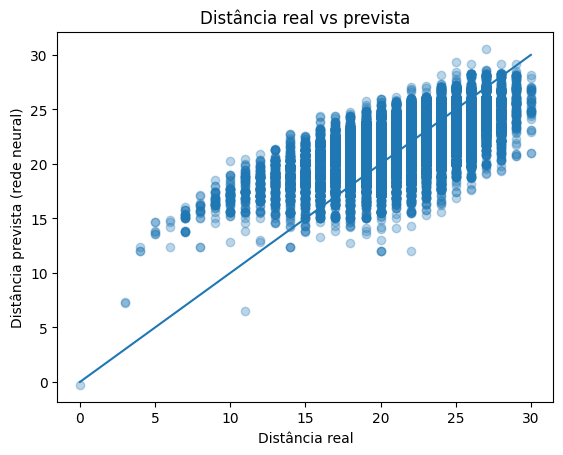

In [18]:
import matplotlib.pyplot as plt

# prever valores no conjunto de teste
pred_nn = modelo_nn.predict(X_test)

plt.figure()

plt.scatter(y_test, pred_nn, alpha=0.3)

plt.xlabel("Distância real")
plt.ylabel("Distância prevista (rede neural)")
plt.title("Distância real vs prevista")

# linha ideal (previsão perfeita)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

10 Erro de previsão

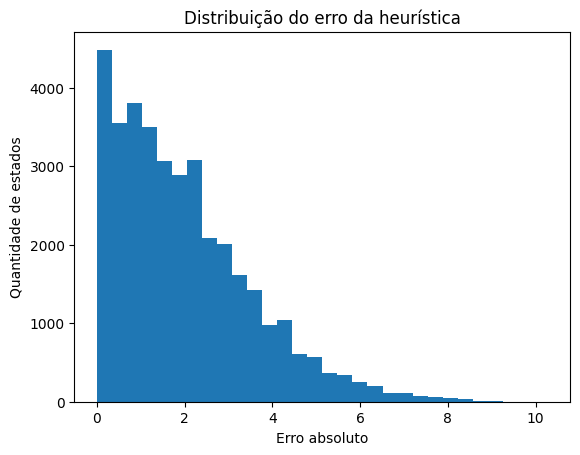

In [19]:
erro = abs(pred_nn - y_test)

plt.figure()

plt.hist(erro, bins=30)

plt.xlabel("Erro absoluto")
plt.ylabel("Quantidade de estados")
plt.title("Distribuição do erro da heurística")

plt.show()

Definir tamanhos de treinamento

Vamos testar vários volumes de dados:

In [20]:
tamanhos = [100, 1000, 5000, 20000, 100000]

Codigo do experimento

In [24]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

erros = []

for n in tamanhos:

    # selecionar amostra aleatória
    sample = df.sample(n=n, random_state=42)

    X_sample = sample.drop(columns=["dist_real"])
    y_sample = sample["dist_real"]

    modelo = MLPRegressor(
        hidden_layer_sizes=(32,16),
        max_iter=200
    )

    modelo.fit(X_sample, y_sample)

    pred = modelo.predict(X_test)

    erro = mean_absolute_error(y_test, pred)

    erros.append(erro)

    print(f"Treino com {n} estados → erro médio: {erro}")

Treino com 100 estados → erro médio: 2.1132260989779894


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Treino com 1000 estados → erro médio: 2.0420035123386753
Treino com 5000 estados → erro médio: 2.0187709524648523
Treino com 20000 estados → erro médio: 2.005709955595139
Treino com 100000 estados → erro médio: 2.0005141127142925


Grafico

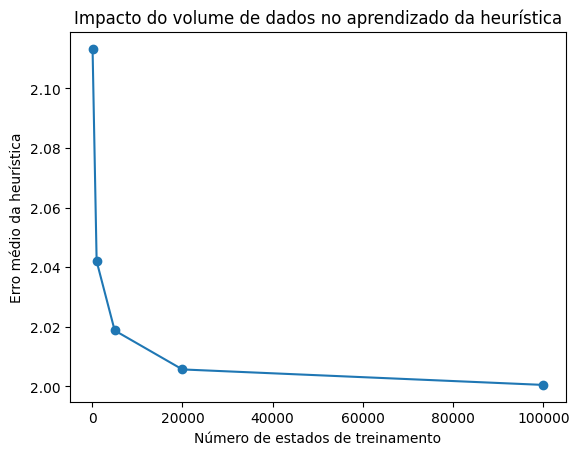

In [25]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(tamanhos, erros, marker="o")

plt.xlabel("Número de estados de treinamento")
plt.ylabel("Erro médio da heurística")
plt.title("Impacto do volume de dados no aprendizado da heurística")

plt.show()